# ***Carga de librerías***


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

# ***Carga de datos***

In [2]:
# Ruta al dataset (ajusta si es necesario)
DATA_PATH = r'..\data\online_retail_II.xlsx'

# Si el Excel tiene varias hojas, podemos cargar la primera o especificar por nombre
#df = pd.read_excel(DATA_PATH, sheet_name=1)
xl = pd.ExcelFile(DATA_PATH)
df = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')

Filas: 1,067,371 | Columnas: 8


In [3]:
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.tail(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [5]:
df.shape

(1067371, 8)

# ***Inspección de datos básico***

In [6]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

# 📊 ***Descripción de Variables del Dataset***

Este dataset contiene información sobre transacciones de ventas. A continuación se describen sus columnas:

| Variable        | Tipo de dato | Descripción |
|----------------|-------------|-------------|
| **Invoice**     | Object | Número único de factura que identifica cada transacción. Si tiene una C es una cancelación|
| **StockCode**   | Object | Código único del producto vendido. |
| **Description** | Object | Descripción del producto. |
| **Quantity**    | Integer | Cantidad de unidades vendidas en la transacción. Puede ser negativa en caso de devoluciones. |
| **InvoiceDate** | DateTime | Fecha y hora en que se realizó la transacción. |
| **Price**       | Float | Precio unitario del producto. |
| **Customer ID** | Float | Identificador único del cliente. Puede haber valores nulos si el cliente no está registrado. |
| **Country**     | Object | País desde donde se realizó la compra. |

---

## 🧾 ***Notas adicionales***

- Cada fila representa una línea de producto dentro de una factura.
- Una misma factura (**Invoice**) puede aparecer varias veces si incluye múltiples productos.
- Valores negativos en **Quantity** suelen indicar devoluciones.
- La columna **Customer ID** puede contener valores faltantes.

---

# ***Dominio del dataset***
Este dataset pertenece al ámbito de las ventas minoristas (retail), específicamente de una tienda o empresa de comercio electrónico que registra transacciones de productos vendidos a clientes.

## ***Características del dominio:***
-   ***Transaccional:*** Cada fila representa una operación de venta (o devolución).
-   ***Comercial:*** Incluye precios, cantidades y productos.
-   ***Orientado a clientes:*** Contiene identificadores de clientes y países.
-   ***Temporal:*** Permite análisis en el tiempo gracias a la variable InvoiceDate.

---

# ***Exploración del dataset***
En este apartado exploraremos todas las columnnas del dataset con la finalidad de encontrar errores, duplicados, nulos o inconcruencias para el posterior uso del dataset.

In [7]:
num_duplicados = df["Invoice"].duplicated().sum()
print(num_duplicados)

num_registros = len(df)
print(num_registros)

num_facturas_unicas = num_registros-num_duplicados
print(f"Numero de facturas unicas: {num_facturas_unicas}")

1013743
1067371
Numero de facturas unicas: 53628


# ***Comprobación de duplicados, nulos y tipos de cada columna***

In [8]:
# Creamos un dataframe resumen con información básica de calidad por columna:
# - Número de valores nulos
# - Número de valores duplicados dentro de cada columna
# - Tipo de dato actual
df_exploratory = pd.DataFrame({
        "nulos" : df.isna().sum(),
        "duplicados" : df.apply(lambda columna: columna.duplicated().sum()),
        "tipo" : df.dtypes
})
df_exploratory

,nulos,duplicados,tipo
Invoice,0,1013743,object
StockCode,0,1062066,object
Description,4382,1061672,object
Quantity,0,1066314,int64
InvoiceDate,0,1019736,datetime64[ns]
Price,0,1064564,float64
Customer ID,243007,1061428,float64
Country,0,1067328,object


In [9]:
df.duplicated().sum()

np.int64(34335)

# 📊***Análisis de Calidad del Dataset***

## ⚠️ 1. Observaciones clave

### 🟡 Valores nulos
- **Customer ID** presenta un número significativo de nulos (243,007)
- **Description** tiene algunos valores faltantes (4,382)
- El resto de columnas no tiene nulos

👉 Esto es crítico para modelos basados en cliente

---

### 🔁 "Duplicados" por columna
- Todas las columnas presentan muchos valores repetidos
- Esto es **normal en datasets transaccionales**

Ejemplos:
- `Invoice`: múltiples productos por factura
- `StockCode` y `Description`: productos repetidos
- `Country`: pocos países
- `Quantity` y `Price`: valores discretos

👉 No indica errores en los datos

---

## 🔎 2. Duplicados reales (filas completas)

### Interpretación:
-   Existen filas completamente idénticas en el dataset

Estas pueden deberse a:
-   registros duplicados reales ⚠️
-   comportamiento legítimo (menos común)

## 3. Próximos pasos recomendados
-   Eliminar nulos en Customer ID
-   Evaluar/eliminar duplicados completos
-   Filtrar devoluciones (Quantity < 0)
-   Agregar variables a nivel cliente para modelado (esto se realizartá en elnotebook de limpieza y transformación o en el del modelo)

# ***Revisión de columnas sospechosas***

In [10]:
# Seleccionamos las columnas categoricas del Dataset excluyendo las numéricas.
non_numeric_cols = df.select_dtypes(exclude=['number']).columns
non_numeric_cols

Index(['Invoice', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object')

In [14]:
# Creamos una lista con todas las columnas categoricas para luego mostrar con un bucle los diferentes valores unicos que puede tener cada columna.
# Esto nos permitirá saber si el tipo de alguna columna no concuerda con el valor designado en las mismas.
columna_categoria_list = [
    "Invoice",
    "StockCode",
    "Description",
    "InvoiceDate",
    "Country" 
]
for i in columna_categoria_list:
    print(f"Columna: {i}")
    print(df[i].unique())
    print("------")

Columna: Invoice
[489434 489435 489436 ... 581585 581586 581587]
------
Columna: StockCode
[85048 '79323P' '79323W' ... 23609 23617 23843]
------
Columna: Description
['15CM CHRISTMAS GLASS BALL 20 LIGHTS' 'PINK CHERRY LIGHTS'
 ' WHITE CHERRY LIGHTS' ... 'mixed up'
 'CREAM HANGING HEART T-LIGHT HOLDER' 'PAPER CRAFT , LITTLE BIRDIE']
------
Columna: InvoiceDate
<DatetimeArray>
['2009-12-01 07:45:00', '2009-12-01 07:46:00', '2009-12-01 09:06:00',
 '2009-12-01 09:08:00', '2009-12-01 09:24:00', '2009-12-01 09:28:00',
 '2009-12-01 09:43:00', '2009-12-01 09:44:00', '2009-12-01 09:46:00',
 '2009-12-01 09:50:00',
 ...
 '2011-12-09 12:09:00', '2011-12-09 12:16:00', '2011-12-09 12:19:00',
 '2011-12-09 12:20:00', '2011-12-09 12:21:00', '2011-12-09 12:23:00',
 '2011-12-09 12:25:00', '2011-12-09 12:31:00', '2011-12-09 12:49:00',
 '2011-12-09 12:50:00']
Length: 47635, dtype: datetime64[ns]
------
Columna: Country
['United Kingdom' 'France' 'USA' 'Belgium' 'Australia' 'EIRE' 'Germany'
 'Portugal' 'Ja

# ***Comprobación de las variables numéricas del dataset***

In [12]:
# Utilizo describe porque aporta toda la informacion como máximo, mínimo, media, etc.
df.describe().round(2)

,Quantity,InvoiceDate,Price,Customer ID
count,1067371.00,1067371,1067371.00,824364.00
mean,9.94,2011-01-02 21:13:55.394028544,4.65,15324.64
min,-80995.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-07-09 09:46:00,1.25,13975.00
50%,3.00,2010-12-07 15:28:00,2.10,15255.00
75%,10.00,2011-07-22 10:23:00,4.15,16797.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,172.71,NaN,123.55,1697.46


## ⚠️ ***Observaciones clave***

### Quantity
- Valores negativos → indican devoluciones
- Valores extremadamente altos → posibles outliers o compras masivas

---

### Price
- Hay precios negativos (posibles errores o ajustes)
- Gran dispersión → presencia de outliers

---

### Customer ID
- Menor número de registros → hay valores nulos
- No es variable numérica útil directamente para modelado (es identificador)

---

### InvoiceDate
- Representa una variable temporal
- No se interpreta directamente con media/desviación
- Debe transformarse en features

---

## 🧠 Conclusiones

-   Existen outliers importantes en `Quantity` y `Price`
-   Hay valores negativos que deben tratarse según el objetivo
-   `Customer ID` tiene valores faltantes
-   Dataset rico en información temporal y transaccional

---

## 🚀 Recomendaciones

1. Eliminar o tratar valores negativos:
```python
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

# ***Búsqueda de incoherencias***

In [13]:
print(f"Número de filas con precio inferior a 0: {(df["Price"] < 0).sum()}")
df[df["Price"] < 0]

Número de filas con precio inferior a 0: 5


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [17]:
# Comprobar si existen devoluciones
print(f"Número de filas con cancelaciones/devoluciones: {(df["Quantity"] < 0).sum()}")
df[df["Quantity"] < 0]

Número de filas con cancelaciones/devoluciones: 22950


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [ ]:
# Comprobar si existen cantidades a 0, no tendria sentido
print(f"Número de filas con cantidades a 0: {(df["Quantity"] == 0).sum()}")
df[df["Quantity"] == 0]

Número de filas con cancelaciones/devoluciones: 0


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [ ]:
# Comprobar si hay precios a 0
print(f"Número de filas con precios a 0: {(df["Price"] == 0).sum()}")
df[df["Price"] == 0]

Número de filas con cancelaciones/devoluciones: 6202


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
1062442,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
1063965,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
1063966,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
1064015,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


In [25]:
# Comprobar si hay clientes nulos
print(f"Número de clientes nulos: {df[df["Customer ID"].isna()].shape}")

Número de clientes nulos: (243007, 8)


In [27]:
# Comprobar si hay facturas con compras + devoluciones mezcladas
df.groupby("Invoice")["Quantity"].apply(lambda x: (x > 0).any() and (x < 0).any()).sum()

np.int64(0)

In [32]:
# Comprobar si hay totales de facturas en negativo
df["TotalPrice"] = df["Quantity"] * df["Price"]

print(f"Número de facturas en negativo: {(df.groupby("Invoice")["TotalPrice"].sum().lt(0).sum())}")


Número de facturas en negativo: 8296


In [30]:
# Comprobar si hay clientes con una sola compra
print(f"Número de clientes con una sola compra: {(df.groupby("Customer ID")["Invoice"].nunique() == 1).sum()}")

Número de clientes con una sola compra: 1461


In [35]:
# Comprobar si hay fechas incoherentes
print(f"Rango de fecha mínima y máxima: {df["InvoiceDate"].min(), df["InvoiceDate"].max()}")


Rango de fecha mínima y máxima: (Timestamp('2009-12-01 07:45:00'), Timestamp('2011-12-09 12:50:00'))


In [40]:
print(f"Comprobar si hay clientes con fechas de compra muy separadas en el tiempo: {df.groupby("Customer ID")["InvoiceDate"].agg(["min", "max"]).shape}")

Comprobar si hay clientes con fechas de compra muy separadas en el tiempo: (5942, 2)


In [20]:
checks = {
    "quantity_negative": (df["Quantity"] < 0).sum(),
    "price_negative": (df["Price"] < 0).sum(),
    "price_zero": (df["Price"] == 0).sum(),
    "quantity_zero": (df["Quantity"] == 0).sum(),
    "customer_null": df["Customer ID"].isna().sum()
}

checks

{'quantity_negative': np.int64(22950),
 'price_negative': np.int64(5),
 'price_zero': np.int64(6202),
 'quantity_zero': np.int64(0),
 'customer_null': np.int64(243007)}

# 🚨 ***Incoherencias en el dataset:***

## Problemas detectados

- **Precios negativos:** 5 filas  
  → Posibles errores o ajustes contables

- **Cantidades negativas (devoluciones):** 22,950 filas  
  → Representan cancelaciones/devoluciones (esperado en retail)

- **Precios igual a 0:** 6,202 filas  
  → Pueden indicar productos gratuitos o datos incorrectos

- **Clientes nulos:** 243,007 filas  
  → No utilizables para análisis a nivel cliente

- **Facturas con total negativo:** 8,296  
  → Probablemente devoluciones completas

---

## Casos especiales

- **Facturas con compras y devoluciones mezcladas:** 0  
  → No se detectaron inconsistencias en este aspecto

- **Cantidades igual a 0:** 0  
  → No hay registros inválidos de este tipo

---

## Rango temporal

- Desde: 2009-12-01  
- Hasta: 2011-12-09  

---

## Conclusión

El dataset presenta:
- ✔️ Estructura coherente de tipo transaccional  
- ⚠️ Presencia de devoluciones (Quantity < 0)  
- ⚠️ Algunos valores atípicos (precios negativos o cero)  
- ⚠️ Alta proporción de clientes sin identificar  

---

## Recomendaciones

- Eliminar o tratar devoluciones según el objetivo del modelo  
- Filtrar precios ≤ 0 si no son relevantes  
- Eliminar registros sin `Customer ID` para modelado de clientes  

# ***Distribución inicial de las columnas***

## ***Distribución de Top 10 países***

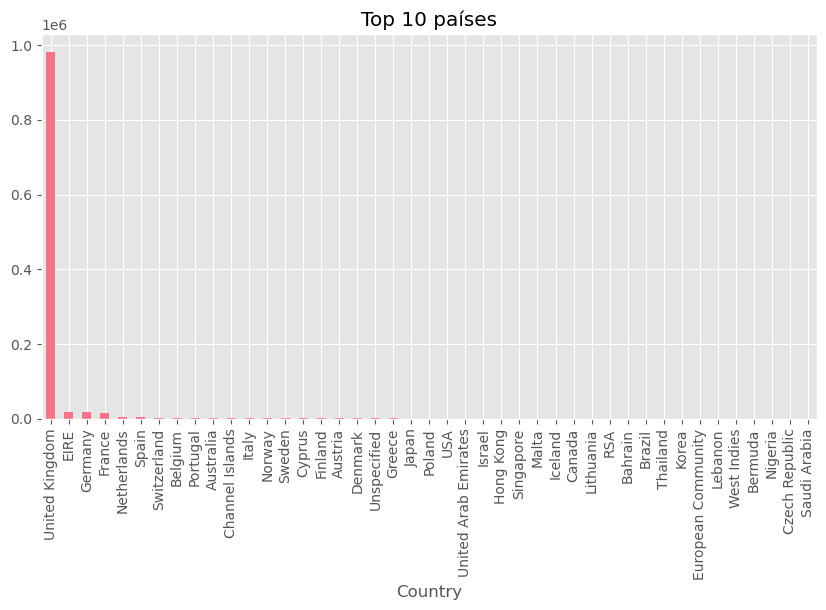

In [53]:
plt.figure(figsize=(10,5))
df["Country"].value_counts().plot(kind="bar")
plt.title("Top 10 países")
plt.show()

-   Se puede apreciar como el pais predominante es Reino Unido, por lo que a nivel transaccional habrá que tener en cuenta que los análisis habría que ponerlos en el contexto principal donde la mayoría de transacciones son realizadas en UK
-   A nivel de cliente, la variable país puede ser poco relevante ya que crea un claro sesgo en el dataset

---

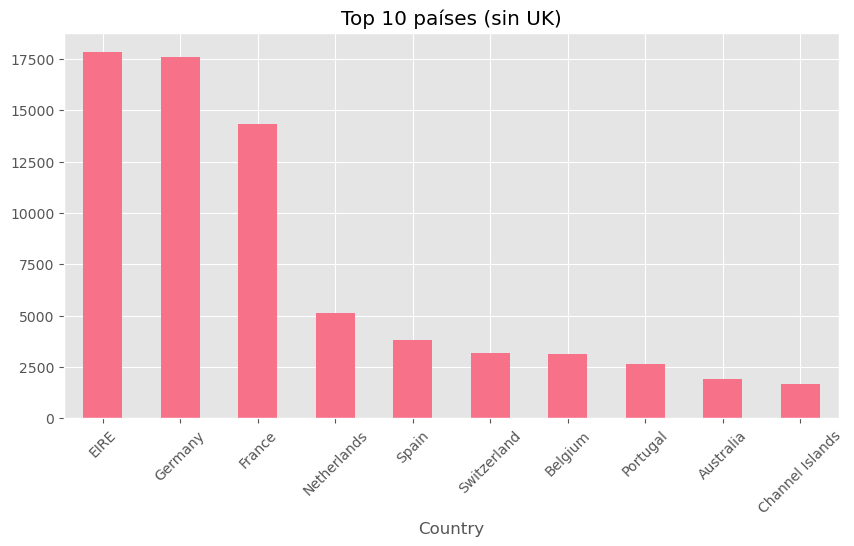

In [57]:
df_no_uk = df[df["Country"] != "United Kingdom"]

plt.figure(figsize=(10,5))
df_no_uk["Country"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 países (sin UK)")
plt.xticks(rotation=45)
plt.show()

-   Con esta nueva gráfica donde excluimos a UK, podemos ver claramente que los 3 paises predominantes después de UK son EIRE(Irlanda), Alemania y Francia, seguidos en menor medida por los demás paises contribuyentes
-   Aún así, la frecuencia de aparición es mucho menor que la de Reino Unido

---

## ***Distribución de compras por cliente <50***

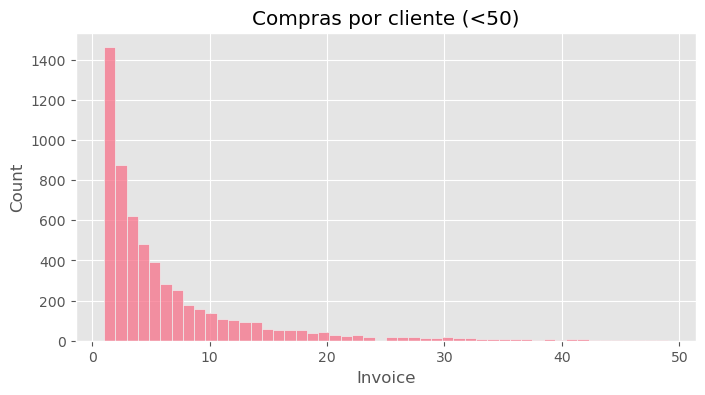

In [59]:
customer_purchases = df.groupby("Customer ID")["Invoice"].nunique()

plt.figure(figsize=(8,4))
sns.histplot(customer_purchases[customer_purchases < 50], bins=50)
plt.title("Compras por cliente (<50)")
plt.show()

-   La mayoria de clientes realizan pocas compras, por eso vemos un claro sesgo hacia la izquierda, mientras que un reducido número de clientes realiza muchas más compras de lo habitual

---

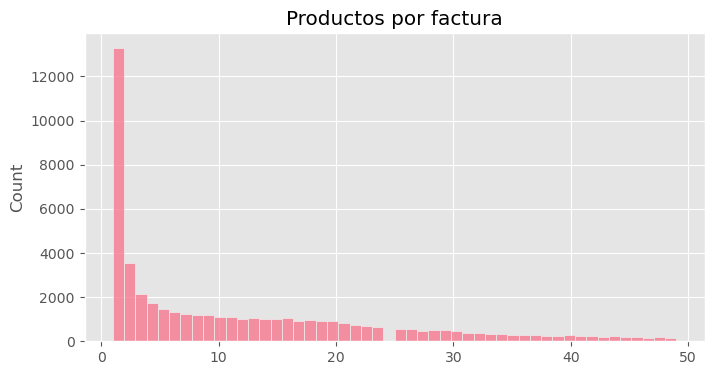

In [66]:
basket_size = df.groupby("Invoice").size()

plt.figure(figsize=(8,4))
sns.histplot(basket_size[basket_size < 50], bins=50)
plt.title("Productos por factura")
plt.show()

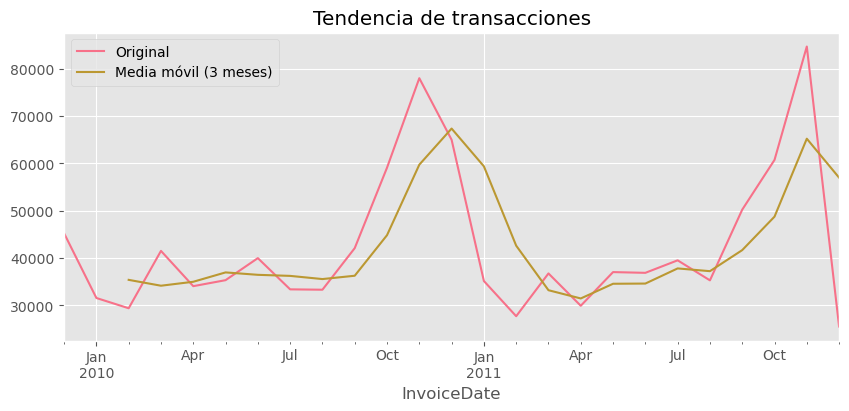

In [68]:
monthly = df.set_index("InvoiceDate").resample("MS").size()

plt.figure(figsize=(10,4))
monthly.plot(label="Original")
monthly.rolling(3).mean().plot(label="Media móvil (3 meses)")
plt.legend()
plt.title("Tendencia de transacciones")
plt.show()

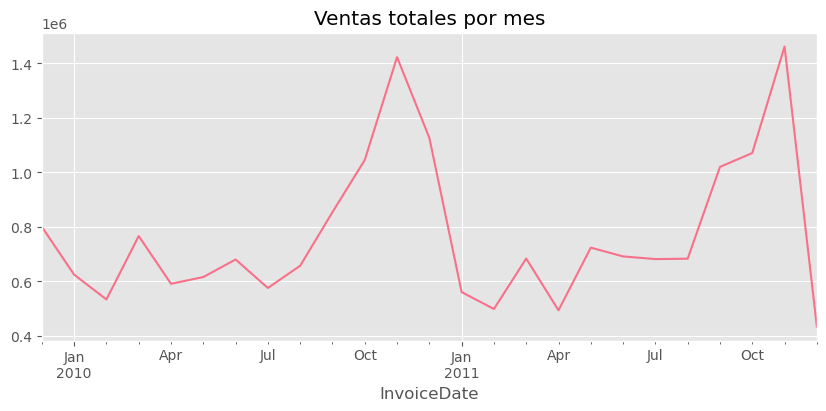

In [69]:
df["TotalPrice"] = df["Quantity"] * df["Price"]

monthly_sales = df.set_index("InvoiceDate").resample("MS")["TotalPrice"].sum()

plt.figure(figsize=(10,4))
monthly_sales.plot()
plt.title("Ventas totales por mes")
plt.show()

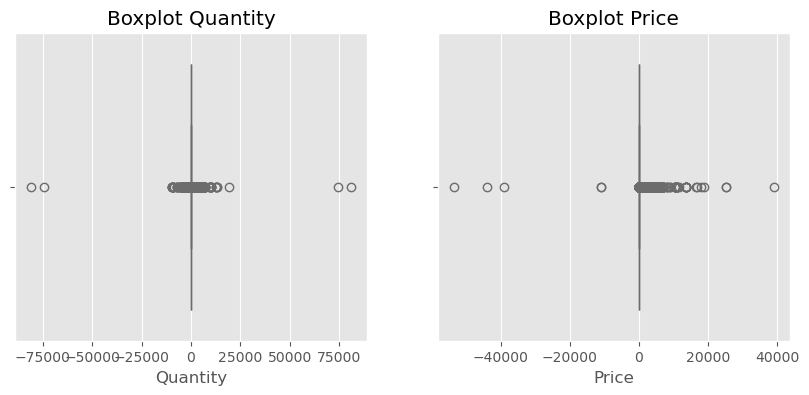

In [65]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df["Quantity"])
plt.title("Boxplot Quantity")

plt.subplot(1,2,2)
sns.boxplot(x=df["Price"])
plt.title("Boxplot Price")

plt.show()